# O1 fixed-depth random-design comparison

This notebook compares SMAC's default 50% random-design injection against 0% random-design injection for fixed depths 5, 8, 12, 15, and 20 on the fixed O1 deterministic benchmark seed.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

DEPTHS = (5, 8, 12, 15, 20)
SEEDS = tuple(range(5))
PROBABILITIES = (0.0, 0.5)
SCENARIO_ORDER = ('random_design_0', 'random_design_50')
SCENARIO_LABELS = {
    'random_design_0': '0% random design',
    'random_design_50': '50% random design',
}
CHECKPOINTS = tuple(range(200, 1001, 200))
METRIC = 'best_so_far'

candidates = [
    Path.cwd(),
    Path.cwd()
    / 'experiments/synthaticBench/o1_deterministic/depth_policies/06_no_random_injection',
]
HERE = next(
    (p for p in candidates if (p / 'o1_fixed_depth_random_design_runner.py').exists()),
    None,
)
if HERE is None:
    raise FileNotFoundError('Run from the notebook directory or repository root.')
OUTPUT = HERE / 'smac_output'
print(HERE.resolve())

/rwthfs/rz/cluster/home/io632776/experiments/adaptive-smac/experiments/synthaticBench/o1_deterministic/depth_policies/06_no_random_injection


## Load trajectories

In [2]:
rows = []
curves = {}

for path in sorted(OUTPUT.rglob('trajectory.json')):
    data = json.loads(path.read_text())
    label = data.get('random_design_label')
    if label not in SCENARIO_ORDER:
        continue
    depth = int(data['max_depth'])
    seed = int(data['smac_seed'])
    values = np.asarray(data[METRIC], dtype=float)
    key = (label, depth, seed)
    if key in curves:
        raise ValueError(f'Duplicate trajectory for {key}')
    curves[key] = values
    rows.append(
        {
            'random_design_label': label,
            'random_design_probability': float(data['random_design_probability']),
            'max_depth': depth,
            'policy': data['policy'],
            'smac_seed': seed,
            'final_best_so_far': float(values[-1]),
            'final_best_regret': float(data['best_regret'][-1]),
            'n_trials': int(data['n_trials']),
            'problem_seed': int(data['problem_seed']),
            'benchmark_seed': int(data['benchmark_seed']),
            'pythonhashseed': str(data['pythonhashseed']),
            'dimension': int(data['dimension']),
            'min_samples_leaf': int(data['min_samples_leaf']),
            'min_samples_split': int(data['min_samples_split']),
            'path': path,
        }
    )

results = pd.DataFrame(rows)
if results.empty:
    raise FileNotFoundError(f'No trajectories found below {OUTPUT}.')

bad = results.query(
    "n_trials != 1000 or problem_seed != 52 or benchmark_seed != 52 "
    "or pythonhashseed != '12345' or max_depth not in @DEPTHS "
    "or random_design_probability not in @PROBABILITIES"
)
if not bad.empty:
    display(bad)
    raise ValueError('Incompatible trajectory metadata.')

counts = (
    results.groupby(['random_design_label', 'max_depth'])['smac_seed']
    .nunique()
    .unstack(fill_value=0)
    .reindex(index=SCENARIO_ORDER, columns=DEPTHS, fill_value=0)
)
missing = [
    (label, depth, seed)
    for label in SCENARIO_ORDER
    for depth in DEPTHS
    for seed in SEEDS
    if (label, depth, seed) not in curves
]

print(f'Loaded {len(results)}/50 expected trajectories.')
print(f'Missing trajectories: {len(missing)}')
display(counts)
if missing:
    display(pd.DataFrame(missing, columns=['random_design_label', 'max_depth', 'smac_seed']))

Loaded 50/50 expected trajectories.
Missing trajectories: 0


max_depth,5,8,12,15,20
random_design_label,,,,,
random_design_0,5,5,5,5,5
random_design_50,5,5,5,5,5


## Trial number vs best so far with confidence intervals

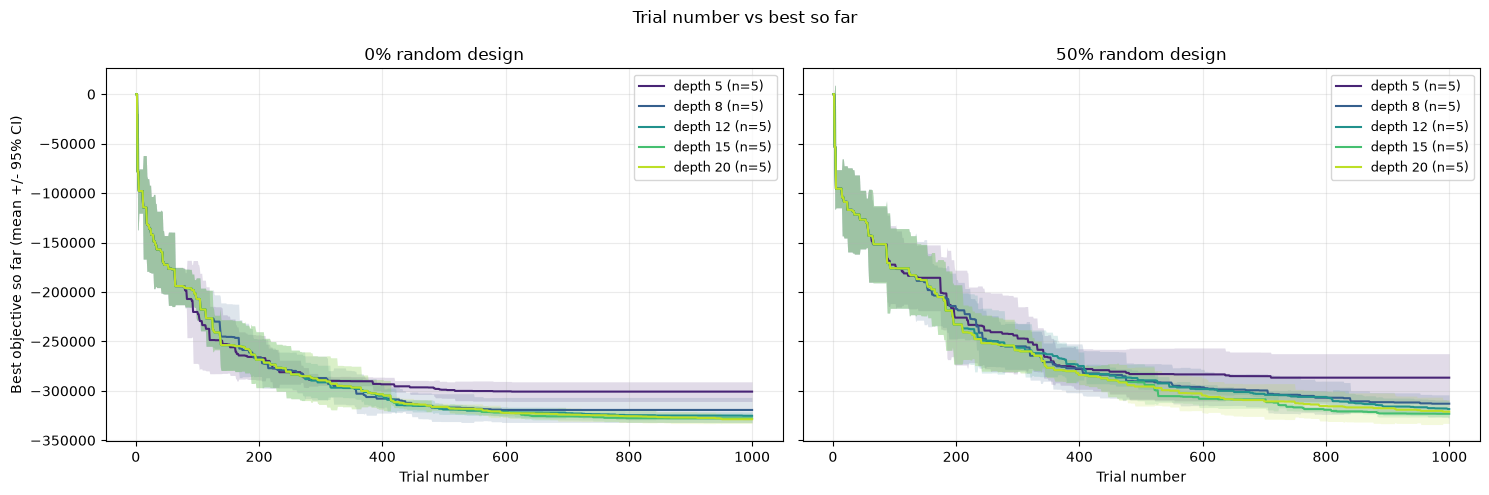

In [3]:
T_CRIT_95 = {2: 12.7062047364, 3: 4.3026527297, 4: 3.1824463053, 5: 2.7764451052}


def curve_summary(label: str, depth: int) -> tuple[np.ndarray, np.ndarray, np.ndarray, int]:
    series = [curves[(label, depth, seed)] for seed in SEEDS if (label, depth, seed) in curves]
    if not series:
        raise ValueError(f'No curves for {label}, depth={depth}')
    min_len = min(len(values) for values in series)
    arr = np.vstack([values[:min_len] for values in series])
    mean = arr.mean(axis=0)
    if arr.shape[0] < 2:
        half_width = np.zeros_like(mean)
    else:
        tcrit = T_CRIT_95.get(arr.shape[0], 1.96)
        half_width = tcrit * arr.std(axis=0, ddof=1) / np.sqrt(arr.shape[0])
    iteration = np.arange(1, min_len + 1)
    return iteration, mean, half_width, arr.shape[0]


fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(DEPTHS)))

for ax, label in zip(axes, SCENARIO_ORDER):
    for color, depth in zip(colors, DEPTHS):
        iteration, mean, half_width, n = curve_summary(label, depth)
        ax.plot(iteration, mean, color=color, label=f'depth {depth} (n={n})')
        ax.fill_between(
            iteration,
            mean - half_width,
            mean + half_width,
            color=color,
            alpha=0.16,
            linewidth=0,
        )
    ax.set_title(SCENARIO_LABELS[label])
    ax.set_xlabel('Trial number')
    ax.grid(alpha=0.25)
    ax.legend(ncol=1, fontsize=9)

axes[0].set_ylabel('Best objective so far (mean +/- 95% CI)')
fig.suptitle('Trial number vs best so far')
fig.tight_layout()
plt.show()

## Boxplots at 200-iteration checkpoints

,random_design_label,max_depth,smac_seed,checkpoint,best_so_far
0,random_design_0,12,0,200,-281362.130617
1,random_design_0,12,0,400,-307047.798404
2,random_design_0,12,0,600,-314587.054728
3,random_design_0,12,0,800,-318854.913463
4,random_design_0,12,0,1000,-320339.456035


TypeError: Axes.boxplot() got an unexpected keyword argument 'labels'

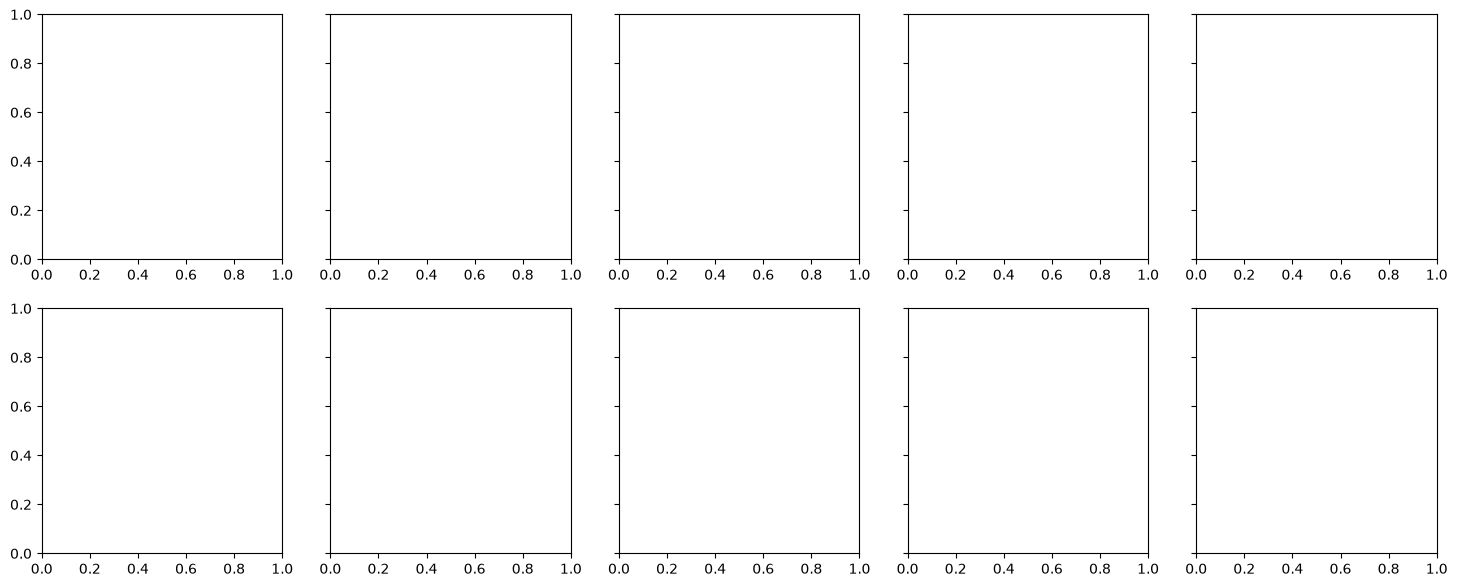

In [4]:
checkpoint_rows = []
for (label, depth, seed), values in curves.items():
    for checkpoint in CHECKPOINTS:
        if len(values) >= checkpoint:
            checkpoint_rows.append(
                {
                    'random_design_label': label,
                    'max_depth': depth,
                    'smac_seed': seed,
                    'checkpoint': checkpoint,
                    'best_so_far': float(values[checkpoint - 1]),
                }
            )

checkpoint_df = pd.DataFrame(checkpoint_rows)
display(checkpoint_df.head())

fig, axes = plt.subplots(
    len(SCENARIO_ORDER),
    len(CHECKPOINTS),
    figsize=(18, 7),
    sharey=True,
)

for row, label in enumerate(SCENARIO_ORDER):
    for col, checkpoint in enumerate(CHECKPOINTS):
        ax = axes[row, col]
        subset = checkpoint_df.query(
            'random_design_label == @label and checkpoint == @checkpoint'
        )
        series = [
            subset.query('max_depth == @depth')['best_so_far'].to_numpy()
            for depth in DEPTHS
        ]
        ax.boxplot(series, labels=[str(depth) for depth in DEPTHS], showmeans=True)
        ax.set_title(f'{SCENARIO_LABELS[label]}\niteration {checkpoint}')
        ax.set_xlabel('Max depth')
        ax.grid(axis='y', alpha=0.25)
        if col == 0:
            ax.set_ylabel('Best objective so far')

fig.suptitle('Best-so-far performance at checkpoints')
fig.tight_layout()
plt.show()

## Final checkpoint table

In [5]:
summary = (
    checkpoint_df.groupby(['random_design_label', 'max_depth', 'checkpoint'])['best_so_far']
    .agg(['count', 'mean', 'std', 'median', 'min', 'max'])
    .reset_index()
)
display(summary.query('checkpoint == 1000').sort_values(['random_design_label', 'mean']))

,random_design_label,max_depth,checkpoint,count,mean,std,median,min,max
24,random_design_0,20,1000,5,-328655.682677,3418.194136,-327235.311116,-332535.303442,-324892.321316
19,random_design_0,15,1000,5,-327811.003619,3562.586870,-328579.034620,-330813.491068,-321696.271390
14,random_design_0,12,1000,5,-325205.747169,3142.959960,-326412.440325,-327747.051041,-320339.456035
9,random_design_0,8,1000,5,-319288.574044,10176.573942,-320568.973196,-328994.078227,-302792.976267
4,random_design_0,5,1000,5,-300745.449193,8003.095668,-299354.050088,-311298.897579,-290005.076336
44,random_design_50,15,1000,5,-323162.326501,2570.283308,-322904.901426,-327351.884037,-320468.559617
49,random_design_50,20,1000,5,-320984.292445,9553.099150,-323556.121449,-330553.533182,-305696.763509
39,random_design_50,12,1000,5,-318395.769686,7201.426721,-319072.810411,-327994.517771,-309459.187707
34,random_design_50,8,1000,5,-312941.627287,7180.610208,-311562.318622,-325157.556175,-306221.403217
29,random_design_50,5,1000,5,-286641.676209,19534.330498,-289112.012779,-307546.374329,-258477.717440
